# Clasificacion Automatica de Tickets con NLP

### Integrantes
* Integrante 1
* Integrante 2
* Integrante 3

## Descripcion del Problema 

Debe crear un modelo que pueda clasificar las quejas (complaints) de los clientes en función de los productos/servicios. Al hacerlo, puede segregar estos tickets en sus categorías relevantes y, por lo tanto, ayudar en la resolución rápida del problema.

Realizará el modelado de temas en los datos <b>.json</b> proporcionados por la empresa. Dado que estos datos no están etiquetados, debe aplicar NMF para analizar patrones y clasificar los tickets en los siguientes cinco grupos según sus productos/servicios:

* Tarjetas de Credito / Tarjetas Prepagadas (Credit card / Prepaid Card)

* Servicios de Cuentas de Banco (Bank account services)

* Reportes de Robos (Theft/Dispute reporting)

* Prestamos Hipotecarios y Otros Prestamos (Mortgages/loans)

* Otros

Con la ayuda del modelado de temas, podrá asignar cada ticket a su respectivo departamento/categoría. Luego puede usar estos datos para entrenar cualquier modelo supervisado, como regresión logística, árbol de decisión o bosque aleatorio. Usando este modelo entrenado, puede clasificar cualquier nuevo ticket de soporte de quejas de clientes en su departamento correspondiente.

## Flujo de Trajajo a Realizar:

Debe realizar las siguientes ocho tareas principales para completar la tarea:

1. Data Loading

2. Text preprocessing

3. Exploratory Data Analysis (EDA)

4. Feature Extraction

5. Topic modeling 

6. Model building using Supervised Learning

7. Model training and evaluation

8. Model inference

## Setup e Importacion de Librerias

In [7]:
## SpaCy and en_core_web_sm installation
#!pip install spacy

##run the following command in the console
#python -m spacy download en_core_web_sm

In [8]:
#!pip install wordcloud

## Importing the necessary libraries

In [9]:
import json
import numpy as np
import pandas as pd
import re, string

# Import NLTK libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Import Spacy libraries
import spacy
import en_core_web_sm
nlp = en_core_web_sm.load()

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from plotly.offline import plot
import plotly.graph_objects as go
import plotly.express as px

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from pprint import pprint

# Suppressing Warnings
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Loading the data

Los datos están en formato JSON y necesitamos convertirlos a un dataframe.

In [11]:
# Cargar archivo JSON
with open('../dataset/complaints.json', 'r') as file:
    data = json.load(file)

# Convertir a DataFrame
df = pd.DataFrame(data)

# Mostrar primeras filas
print(f"📊 Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

📊 Dataset cargado: 78313 filas, 5 columnas


,_index,_type,_id,_score,_source
0,complaint-public-v2,complaint,3211475,0.0,"{'tags': None, 'zip_code': '90301', 'complaint..."
1,complaint-public-v2,complaint,3229299,0.0,"{'tags': 'Servicemember', 'zip_code': '319XX',..."
2,complaint-public-v2,complaint,3199379,0.0,"{'tags': None, 'zip_code': '77069', 'complaint..."
3,complaint-public-v2,complaint,2673060,0.0,"{'tags': None, 'zip_code': '48066', 'complaint..."
4,complaint-public-v2,complaint,3203545,0.0,"{'tags': None, 'zip_code': '10473', 'complaint..."


## Data preparation

In [12]:
# Expandir la columna '_source' que contiene datos anidados
df = pd.json_normalize(data)

print("="*80)
print("📊 DATAFRAME EXPANDIDO")
print("="*80)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nColumnas disponibles:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

📊 DATAFRAME EXPANDIDO
Dimensiones: 78313 filas × 22 columnas

Columnas disponibles:
  1. _index
  2. _type
  3. _id
  4. _score
  5. _source.tags
  6. _source.zip_code
  7. _source.complaint_id
  8. _source.issue
  9. _source.date_received
  10. _source.state
  11. _source.consumer_disputed
  12. _source.product
  13. _source.company_response
  14. _source.company
  15. _source.submitted_via
  16. _source.date_sent_to_company
  17. _source.company_public_response
  18. _source.sub_product
  19. _source.timely
  20. _source.complaint_what_happened
  21. _source.sub_issue
  22. _source.consumer_consent_provided


In [13]:
df.head()

,_index,_type,_id,_score,_source.tags,_source.zip_code,_source.complaint_id,_source.issue,_source.date_received,_source.state,...,_source.company_response,_source.company,_source.submitted_via,_source.date_sent_to_company,_source.company_public_response,_source.sub_product,_source.timely,_source.complaint_what_happened,_source.sub_issue,_source.consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [14]:
# Diccionario de mapeo
rename_dict = {
    '_index': 'source_index',
    '_type': 'record_type',
    '_id': 'record_id',
    '_score': 'search_score',
    '_source.tags': 'tags',
    '_source.zip_code': 'zip_code',
    '_source.complaint_id': 'complaint_id',
    '_source.issue': 'issue',
    '_source.date_received': 'date_received',
    '_source.state': 'state',
    '_source.consumer_disputed': 'consumer_disputed',
    '_source.product': 'product',
    '_source.company_response': 'company_response',
    '_source.company': 'company',
    '_source.submitted_via': 'submitted_via',
    '_source.date_sent_to_company': 'date_sent_to_company',
    '_source.company_public_response': 'company_public_response',
    '_source.sub_product': 'sub_product',
    '_source.timely': 'timely',
    '_source.complaint_what_happened': 'complaint_text',
    '_source.sub_issue': 'sub_issue',
    '_source.consumer_consent_provided': 'consumer_consent_provided'
}

# Renombrar columnas del DataFrame
df = df.rename(columns=rename_dict)

# Verificar resultado
print("Nuevos nombres de columnas:", df.columns.tolist())
df.head()


Nuevos nombres de columnas: ['source_index', 'record_type', 'record_id', 'search_score', 'tags', 'zip_code', 'complaint_id', 'issue', 'date_received', 'state', 'consumer_disputed', 'product', 'company_response', 'company', 'submitted_via', 'date_sent_to_company', 'company_public_response', 'sub_product', 'timely', 'complaint_text', 'sub_issue', 'consumer_consent_provided']


,source_index,record_type,record_id,search_score,tags,zip_code,complaint_id,issue,date_received,state,...,company_response,company,submitted_via,date_sent_to_company,company_public_response,sub_product,timely,complaint_text,sub_issue,consumer_consent_provided
0,complaint-public-v2,complaint,3211475,0.0,None,90301,3211475,Attempts to collect debt not owed,2019-04-13T12:00:00-05:00,CA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-13T12:00:00-05:00,None,Credit card debt,Yes,,Debt is not yours,Consent not provided
1,complaint-public-v2,complaint,3229299,0.0,Servicemember,319XX,3229299,Written notification about debt,2019-05-01T12:00:00-05:00,GA,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-05-01T12:00:00-05:00,None,Credit card debt,Yes,Good morning my name is XXXX XXXX and I apprec...,Didn't receive enough information to verify debt,Consent provided
2,complaint-public-v2,complaint,3199379,0.0,None,77069,3199379,"Other features, terms, or problems",2019-04-02T12:00:00-05:00,TX,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2019-04-02T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,I upgraded my XXXX XXXX card in XX/XX/2018 and...,Problem with rewards from credit card,Consent provided
3,complaint-public-v2,complaint,2673060,0.0,None,48066,2673060,Trouble during payment process,2017-09-13T12:00:00-05:00,MI,...,Closed with explanation,JPMORGAN CHASE & CO.,Web,2017-09-14T12:00:00-05:00,None,Conventional home mortgage,Yes,,None,Consent not provided
4,complaint-public-v2,complaint,3203545,0.0,None,10473,3203545,Fees or interest,2019-04-05T12:00:00-05:00,NY,...,Closed with explanation,JPMORGAN CHASE & CO.,Referral,2019-04-05T12:00:00-05:00,None,General-purpose credit card or charge card,Yes,,Charged too much interest,N/A


In [15]:
# Cualquier string vacío en complaint_text se pone como NaN
df['complaint_text'] = df['complaint_text'].replace('', np.nan)

# Verificar cantidad de nulos
print("Cantidad de valores nulos en complaint_text:", df['complaint_text'].isnull().sum())


Cantidad de valores nulos en complaint_text: 57241


In [16]:
# Eliminar todas las filas donde complaint_text es NaN
df = df.dropna(subset=['complaint_text'])

# Chequeo de control
print("Dimensiones del dataframe tras eliminar textos nulos:", df.shape)

Dimensiones del dataframe tras eliminar textos nulos: (21072, 22)


## Prepare the text for topic modeling

Una vez que haya eliminado todas las quejas en blanco, debe:

* Make the text lowercase
* Remove text in square brackets
* Remove punctuation
* Remove words containing numbers

Una vez que haya realizado estas operaciones de limpieza, debe realizar lo siguiente:

* Lemmatize the texts
* Extract the POS tags of the lemmatized text and remove all the words which have tags other than NN[tag == "NN"].


In [17]:
def clean_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Quitar texto entre corchetes []
    text = re.sub(r'\[.*?\]', '', text)
    # Quitar puntuación
    text = re.sub(rf"[{string.punctuation}]", '', text)
    # Quitar palabras que contienen números
    text = re.sub(r'\w*\d\w*', '', text)
    # Quitar espacios extra
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['complaint_clean'] = df['complaint_text'].apply(clean_text)
print(df[['complaint_text', 'complaint_clean']].head(3))


                                       complaint_text  \
1   Good morning my name is XXXX XXXX and I apprec...   
2   I upgraded my XXXX XXXX card in XX/XX/2018 and...   
10  Chase Card was reported on XX/XX/2019. However...   

                                      complaint_clean  
1   good morning my name is xxxx xxxx and i apprec...  
2   i upgraded my xxxx xxxx card in and was told b...  
10  chase card was reported on however fraudulent ...  


In [18]:
nlp = spacy.load('en_core_web_sm') # Ya debe estar cargado en tu notebook

def lemmatize_and_get_nouns(text):
    doc = nlp(text)
    # Extraer solo lemas donde el tag sea NN (sustantivo)
    nouns = [token.lemma_ for token in doc if token.tag_ == 'NN']
    return ' '.join(nouns)

# Puedes agregar un tqdm para ver progreso si tienes muchos textos
from tqdm import tqdm
tqdm.pandas()
df['complaint_nouns'] = df['complaint_clean'].progress_apply(lemmatize_and_get_nouns)
print(df[['complaint_clean', 'complaint_nouns']].head(3))


100%|██████████| 21072/21072 [10:58<00:00, 32.00it/s]

                                      complaint_clean  \
1   good morning my name is xxxx xxxx and i apprec...   
2   i upgraded my xxxx xxxx card in and was told b...   
10  chase card was reported on however fraudulent ...   

                                      complaint_nouns  
1   morning name stop debt verification statement ...  
2   card agent anniversary date agent information ...  
10  chase card application identity consent credit...  


In [19]:
# Sólo las columnas de texto original y texto lematizado
df_clean = df[['complaint_text', 'complaint_nouns']].copy()

print(df_clean.head(3))
print(f"Dimensiones del nuevo dataframe df_clean: {df_clean.shape}")


                                       complaint_text  \
1   Good morning my name is XXXX XXXX and I apprec...   
2   I upgraded my XXXX XXXX card in XX/XX/2018 and...   
10  Chase Card was reported on XX/XX/2019. However...   

                                      complaint_nouns  
1   morning name stop debt verification statement ...  
2   card agent anniversary date agent information ...  
10  chase card application identity consent credit...  
Dimensiones del nuevo dataframe df_clean: (21072, 2)


In [20]:
df_clean

,complaint_text,complaint_nouns
1,Good morning my name is XXXX XXXX and I apprec...,morning name stop debt verification statement ...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,card agent anniversary date agent information ...
10,Chase Card was reported on XX/XX/2019. However...,chase card application identity consent credit...
11,"On XX/XX/2018, while trying to book a XXXX XX...",ticket offer ticket card information offer min...
14,my grand son give me check for {$1600.00} i de...,son check chase account fund chase bank accoun...
...,...,...
78303,After being a Chase Card customer for well ove...,chase card customer decade credit chase bonus ...
78309,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...",credit card provider claim purchase protection...
78310,I am not familiar with XXXX pay and did not un...,pay risk chase bank app chase banking merchant...
78311,I have had flawless credit for 30 yrs. I've ha...,credit yrs credit freedom balance life plenty ...


In [21]:
#Write your function to extract the POS tags 

def pos_tag(text):
    doc = nlp(text)
    nouns = [token.lemma_ for token in doc if token.tag_ == "NN"]
    return " ".join(nouns)

df_clean["complaint_POS_removed"] = df_clean["complaint_text"].apply(pos_tag)#this column should contain lemmatized text with all the words removed which have tags other than NN[tag == "NN"].


In [22]:
#The clean dataframe should now contain the raw complaint, lemmatized complaint and the complaint after removing POS tags.
df_clean

,complaint_text,complaint_nouns,complaint_POS_removed
1,Good morning my name is XXXX XXXX and I apprec...,morning name stop debt verification statement ...,morning name xxxx stop cardmember debt verific...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,card agent anniversary date agent information ...,card agent anniversary date agent information ...
10,Chase Card was reported on XX/XX/2019. However...,chase card application identity consent credit...,application identity consent credit identity a...
11,"On XX/XX/2018, while trying to book a XXXX XX...",ticket offer ticket card information offer min...,xxxx ticket offer ticket card information offe...
14,my grand son give me check for {$1600.00} i de...,son check chase account fund chase bank accoun...,son check chase account fund chase bank accoun...
...,...,...,...
78303,After being a Chase Card customer for well ove...,chase card customer decade credit chase bonus ...,customer decade credit bonus airline hotel fee...
78309,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...",credit card provider claim purchase protection...,xxxx provider claim purchase protection benefi...
78310,I am not familiar with XXXX pay and did not un...,pay risk chase bank app chase banking merchant...,pay risk bank app banking merchant merchant co...
78311,I have had flawless credit for 30 yrs. I've ha...,credit yrs credit freedom balance life plenty ...,credit credit balance life plenty experience b...


## Exploratory data analysis to get familiar with the data.

Escriba el código en esta tarea para realizar lo siguiente:

* Visualiza los datos según la longitud del carácteres 'Complaint'
* Usando una nube de palabras, encuentre las top 40 palabras más frecuentes de todos los artículos después de procesar el texto
* Encuentre los mejores unigramas, bigramas y trigramas por frecuencia entre todas las quejas después de procesar el texto. '

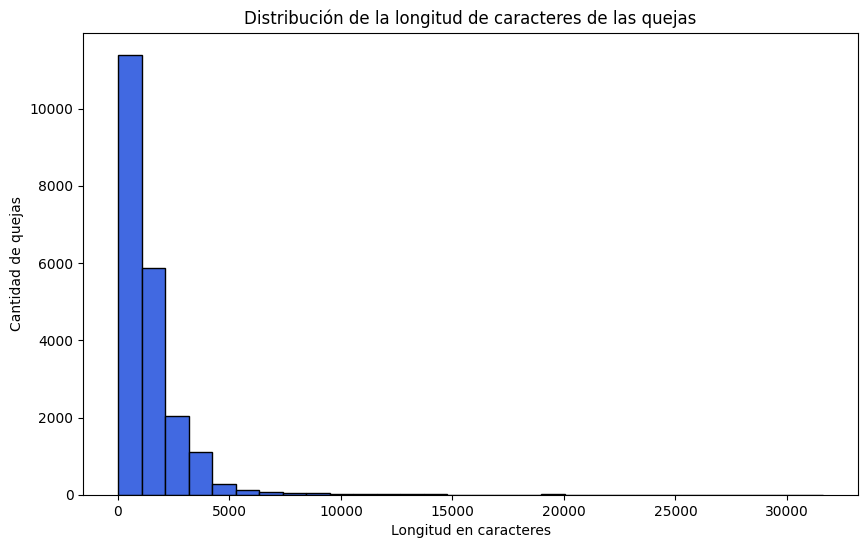

In [23]:
# Write your code here to visualise the data according to the 'Complaint' character length
# Calcula la longitud de cada queja en caracteres
df_clean['complaint_length'] = df_clean['complaint_text'].str.len()

plt.figure(figsize=(10,6))
plt.hist(df_clean['complaint_length'], bins=30, color='royalblue', edgecolor='black')
plt.title("Distribución de la longitud de caracteres de las quejas")
plt.xlabel("Longitud en caracteres")
plt.ylabel("Cantidad de quejas")
plt.show()

#### Find the top 40 words by frequency among all the articles after processing the text.

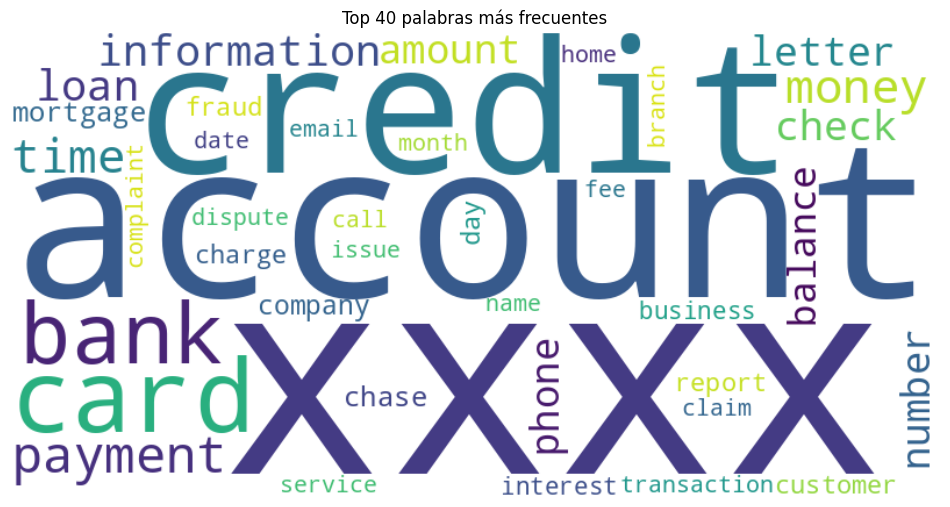

In [25]:
#Using a word cloud find the top 40 words by frequency among all the articles after processing the text
from wordcloud import WordCloud
from collections import Counter

# Une todos los textos procesados en una sola cadena
all_text = " ".join(df_clean['complaint_POS_removed'])

# Extrae las palabras más frecuentes
word_freq = Counter(all_text.split())
most_common = dict(word_freq.most_common(40))

# Genera la nube de palabras solo para las top 40
wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(most_common)

plt.figure(figsize=(12,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Top 40 palabras más frecuentes")
plt.show()


In [26]:
#Removing -PRON- from the text corpus
df_clean['Complaint_clean'] = df_clean['complaint_POS_removed'].str.replace('-PRON-', '')

#### Find the top unigrams,bigrams and trigrams by frequency among all the complaints after processing the text.

In [27]:
#Write your code here to find the top 30 unigram frequency among the complaints in the cleaned datafram(df_clean).
vectorizer_uni = CountVectorizer(ngram_range=(1,1))
X_uni = vectorizer_uni.fit_transform(df_clean['complaint_POS_removed'].dropna().astype(str).tolist())
uni_freq = zip(vectorizer_uni.get_feature_names_out(), X_uni.sum(axis=0).flat)
top_unigrams = sorted(uni_freq, key=lambda x: x[1], reverse=True)[:30]

In [28]:
#Print the top 10 words in the unigram frequency
print("Top 10 Unigramas más frecuentes:")
for word, freq in top_unigrams[:10]:
    print(f"{word}: {freq}")

Top 10 Unigramas más frecuentes:
xxxx: 66478
account: 41089
credit: 29018
card: 24328
bank: 16298
payment: 13622
time: 12030
money: 11902
information: 9554
loan: 9304


In [29]:
#Write your code here to find the top 30 bigram frequency among the complaints in the cleaned datafram(df_clean).
vectorizer_bi = CountVectorizer(ngram_range=(2,2))
X_bi = vectorizer_bi.fit_transform(df_clean['complaint_POS_removed'].dropna().astype(str).tolist())
bi_freq = zip(vectorizer_bi.get_feature_names_out(), X_bi.sum(axis=0).flat)
top_bigrams = sorted(bi_freq, key=lambda x: x[1], reverse=True)[:30]

In [30]:
#Print the top 10 words in the bigram frequency
print("Top 10 Bigramas más frecuentes:")
for bigram, freq in top_bigrams[:10]:
    print(f"{bigram}: {freq}")

Top 10 Bigramas más frecuentes:
xxxx xxxx: 35153
credit card: 9625
account account: 3305
credit report: 3086
checking account: 2613
customer service: 2585
bank account: 2241
debit card: 1746
account xxxx: 1558
credit score: 1551


In [31]:
#Write your code here to find the top 30 trigram frequency among the complaints in the cleaned datafram(df_clean).
vectorizer_tri = CountVectorizer(ngram_range=(3,3))
X_tri = vectorizer_tri.fit_transform(df_clean['complaint_POS_removed'].dropna().astype(str).tolist())
tri_freq = zip(vectorizer_tri.get_feature_names_out(), X_tri.sum(axis=0).flat)
top_trigrams = sorted(tri_freq, key=lambda x: x[1], reverse=True)[:30]


In [32]:
#Print the top 10 words in the trigram frequency
print("Top 10 Trigramas más frecuentes:")
for trigram, freq in top_trigrams[:10]:
    print(f"{trigram}: {freq}")

Top 10 Trigramas más frecuentes:
xxxx xxxx xxxx: 21514
credit card account: 825
credit card company: 726
xxxx xxxx account: 620
credit card credit: 612
account xxxx xxxx: 573
card credit card: 468
card xxxx xxxx: 415
xxxx credit card: 398
account credit card: 381


## The personal details of customer has been masked in the dataset with xxxx. Let's remove the masked text as this will be of no use for our analysis

In [33]:
df_clean['Complaint_clean'] = df_clean['Complaint_clean'].str.replace('xxxx','')

In [34]:
#All masked texts has been removed
df_clean

,complaint_text,complaint_nouns,complaint_POS_removed,complaint_length,Complaint_clean
1,Good morning my name is XXXX XXXX and I apprec...,morning name stop debt verification statement ...,morning name xxxx stop cardmember debt verific...,486,morning name stop cardmember debt verificatio...
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,card agent anniversary date agent information ...,card agent anniversary date agent information ...,355,card agent anniversary date agent information ...
10,Chase Card was reported on XX/XX/2019. However...,chase card application identity consent credit...,application identity consent credit identity a...,224,application identity consent credit identity a...
11,"On XX/XX/2018, while trying to book a XXXX XX...",ticket offer ticket card information offer min...,xxxx ticket offer ticket card information offe...,1502,ticket offer ticket card information offer mi...
14,my grand son give me check for {$1600.00} i de...,son check chase account fund chase bank accoun...,son check chase account fund chase bank accoun...,477,son check chase account fund chase bank accoun...
...,...,...,...,...,...
78303,After being a Chase Card customer for well ove...,chase card customer decade credit chase bonus ...,customer decade credit bonus airline hotel fee...,679,customer decade credit bonus airline hotel fee...
78309,"On Wednesday, XX/XX/XXXX I called Chas, my XXX...",credit card provider claim purchase protection...,xxxx provider claim purchase protection benefi...,2114,provider claim purchase protection benefit sc...
78310,I am not familiar with XXXX pay and did not un...,pay risk chase bank app chase banking merchant...,pay risk bank app banking merchant merchant co...,2319,pay risk bank app banking merchant merchant co...
78311,I have had flawless credit for 30 yrs. I've ha...,credit yrs credit freedom balance life plenty ...,credit credit balance life plenty experience b...,2171,credit credit balance life plenty experience b...


## Feature Extraction
Convierta los textos sin procesar en una matriz de características TF-IDF

**max_df** is used for removing terms that appear too frequently, also known as "corpus-specific stop words"
max_df = 0.95 means "ignore terms that appear in more than 95% of the complaints"

**min_df** is used for removing terms that appear too infrequently
min_df = 2 means "ignore terms that appear in less than 2 complaints"

In [35]:
# Write your code here to initialise the TfidfVectorizer 
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_clean['complaint_POS_removed'].dropna().astype(str).tolist())

#### Create a document term matrix using fit_transform

The contents of a document term matrix are tuples of (complaint_id,token_id) tf-idf score:
The tuples that are not there have a tf-idf score of 0

In [36]:
# Write your code here to create the Document Term Matrix by transforming the complaints column present in df_clean.
dtm = tfidf_vectorizer.fit_transform(df_clean['complaint_POS_removed'].dropna().astype(str).tolist())

## Topic Modelling using NMF

Non-Negative Matrix Factorization (NMF) es una técnica no supervisada, por lo que no hay etiquetas de temas en los que se entrenará el modelo. La forma en que funciona es que NMF descompone (o factoriza) vectores de alta dimensión en una representación de menor dimensión. Estos vectores de menor dimensión no son negativos, lo que también significa que sus coeficientes no son negativos.

En esta tarea tienes que realizar lo siguiente:

* Find the best number of clusters 
* Apply the best number to create word clusters
* Inspect & validate the correction of each cluster wrt the complaints 
* Correct the labels if needed 
* Map the clusters to topics/cluster names

* Encuentra el mejor número de clústeres
* Aplicar el mejor número para crear grupos de palabras
* Inspeccionar y validar la corrección de cada grupo frente a las quejas (Complaints)
* Corrija las etiquetas si es necesario
* Mapear el grupo de nombres de topicos/clusters

In [37]:
from sklearn.decomposition import NMF

## Manual Topic Modeling
Debe adoptar el enfoque de prueba y error para encontrar la mejor cantidad de topicos para su modelo NMF.

El único parámetro que se requiere es el número de componentes, es decir, el número de topicos que queremos. Este es el paso más crucial en todo el proceso de modelado de topicos y afectará en gran medida la calidad de sus topicos finales.

In [38]:
#Load your nmf_model with the n_components i.e 5
num_topics = 5  # Puedes cambiar este valor para probar diferentes cantidades de tópicos

#keep the random_state =40
nmf_model = NMF(n_components=num_topics, random_state=40)

In [39]:
nmf_model.fit(dtm)
len(tfidf_vectorizer.get_feature_names_out())


5484

In [40]:
# Print the Top15 words for each of the topics
feature_names = tfidf_vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(nmf_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[:-16:-1]]
    print(f"Tema {topic_idx}: {', '.join(top_words)}")


Tema 0: credit, report, inquiry, score, information, debt, account, limit, reporting, history, application, identity, letter, company, bureaus
Tema 1: xxxx, number, information, name, letter, dispute, phone, complaint, case, email, address, debt, claim, fraud, charge
Tema 2: account, bank, money, check, checking, branch, deposit, chase, business, number, fraud, transaction, claim, day, balance
Tema 3: payment, loan, mortgage, interest, modification, home, rate, time, balance, month, amount, property, foreclosure, house, date
Tema 4: card, credit, charge, balance, fee, interest, fraud, company, dispute, chase, purchase, debit, merchant, time, statement


In [41]:
#C# Create the best topic for each complaint in terms of integer value 0,1,2,3 & 4
topic_values = nmf_model.transform(dtm)
best_topic = topic_values.argmax(axis=1)


In [43]:
#Assign the best topic to each of the cmplaints in Topic Column

df_clean['Topic'] = best_topic #write your code to assign topics to each rows.

In [44]:
df_clean.head()

,complaint_text,complaint_nouns,complaint_POS_removed,complaint_length,Complaint_clean,Topic
1,Good morning my name is XXXX XXXX and I apprec...,morning name stop debt verification statement ...,morning name xxxx stop cardmember debt verific...,486,morning name stop cardmember debt verificatio...,1
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,card agent anniversary date agent information ...,card agent anniversary date agent information ...,355,card agent anniversary date agent information ...,4
10,Chase Card was reported on XX/XX/2019. However...,chase card application identity consent credit...,application identity consent credit identity a...,224,application identity consent credit identity a...,0
11,"On XX/XX/2018, while trying to book a XXXX XX...",ticket offer ticket card information offer min...,xxxx ticket offer ticket card information offe...,1502,ticket offer ticket card information offer mi...,0
14,my grand son give me check for {$1600.00} i de...,son check chase account fund chase bank accoun...,son check chase account fund chase bank accoun...,477,son check chase account fund chase bank accoun...,2


In [45]:
#Print the first 5 Complaint for each of the Topics
df_clean=df_clean.groupby('Topic').head(5)
df_clean.sort_values('Topic')

,complaint_text,complaint_nouns,complaint_POS_removed,complaint_length,Complaint_clean,Topic
11,"On XX/XX/2018, while trying to book a XXXX XX...",ticket offer ticket card information offer min...,xxxx ticket offer ticket card information offe...,1502,ticket offer ticket card information offer mi...,0
10,Chase Card was reported on XX/XX/2019. However...,chase card application identity consent credit...,application identity consent credit identity a...,224,application identity consent credit identity a...,0
15,Can you please remove inquiry,inquiry,inquiry,29,inquiry,0
23,I have a Chase credit card which is incorrectl...,credit card credit report company issue,credit card credit report company issue,129,credit card credit report company issue,0
26,I have reached out to XXXX several times in at...,attempt inquiry creditor inquiry report chase ...,attempt inquiry creditor inquiry report chase ...,753,attempt inquiry creditor inquiry report chase ...,0
48,"JP Morgan Chase Bank, please answer the follow...",information reason information chase account r...,information xxxx xxxx reason information xxxx ...,1229,information reason information routing num...,1
1,Good morning my name is XXXX XXXX and I apprec...,morning name stop debt verification statement ...,morning name xxxx stop cardmember debt verific...,486,morning name stop cardmember debt verificatio...,1
81,I bought a new XXXX XXXX on XX/XX/XXXX from XX...,loan title chase time resolution time nothing ...,xxxx xxxx xxxx xxxx xxxx loan chase title chas...,437,loan chase title chase time resolution ti...,1
73,I have wired through one of Chase branches in ...,chase reinstatement amount order foreclosure p...,order foreclosure property trustee xxxx xxxx x...,1143,order foreclosure property trustee order fo...,1
93,On XX/XX/2019 we purchased a service with XXXX...,service group snorkeling dispute island itiner...,service xxxx xxxx xxxx xxxx xxxx xxxx group sn...,1539,service group snorkeling dispute isl...,1


#### After evaluating the mapping, if the topics assigned are correct then assign these names to the relevant topic:
* Bank Account services
* Credit card or prepaid card
* Theft/Dispute Reporting
* Mortgage/Loan
* Others

In [46]:
# Create the dictionary of Topic names and Topics
Topic_names = {
    0: "Bank Account services",
    1: "Credit card or prepaid card",
    2: "Theft/Dispute Reporting",
    3: "Mortgage/Loan",
    4: "Others"
}

# Replace Topics with Topic Names
df_clean['Topic'] = df_clean['Topic'].map(Topic_names)


In [47]:
df_clean

,complaint_text,complaint_nouns,complaint_POS_removed,complaint_length,Complaint_clean,Topic
1,Good morning my name is XXXX XXXX and I apprec...,morning name stop debt verification statement ...,morning name xxxx stop cardmember debt verific...,486,morning name stop cardmember debt verificatio...,Credit card or prepaid card
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,card agent anniversary date agent information ...,card agent anniversary date agent information ...,355,card agent anniversary date agent information ...,Others
10,Chase Card was reported on XX/XX/2019. However...,chase card application identity consent credit...,application identity consent credit identity a...,224,application identity consent credit identity a...,Bank Account services
11,"On XX/XX/2018, while trying to book a XXXX XX...",ticket offer ticket card information offer min...,xxxx ticket offer ticket card information offe...,1502,ticket offer ticket card information offer mi...,Bank Account services
14,my grand son give me check for {$1600.00} i de...,son check chase account fund chase bank accoun...,son check chase account fund chase bank accoun...,477,son check chase account fund chase bank accoun...,Theft/Dispute Reporting
15,Can you please remove inquiry,inquiry,inquiry,29,inquiry,Bank Account services
17,With out notice J.P. Morgan Chase restricted m...,notice account debit card branch customer serv...,notice account debit card branch customer serv...,2277,notice account debit card branch customer serv...,Theft/Dispute Reporting
20,"During the summer months, I experience a decli...",summer decline income employment month payment...,summer decline income employment month payment...,1396,summer decline income employment month payment...,Mortgage/Loan
21,"On XXXX XX/XX/2019, I made a {$300.00} payment...",payment retailer chase pay chase website scam ...,payment retailer pay website scam website conf...,3541,payment retailer pay website scam website conf...,Theft/Dispute Reporting
23,I have a Chase credit card which is incorrectl...,credit card credit report company issue,credit card credit report company issue,129,credit card credit report company issue,Bank Account services


## Supervised model to predict any new complaints to the relevant Topics.

Hasta ahora ha creado el modelo para crear los temas para cada queja. Entonces, en la siguiente sección, los utilizará para clasificar cualquier queja nueva.

Dado que utilizará la técnica de aprendizaje supervisado, tenemos que convertir los nombres de los temas en números (las matrices numpy solo entienden los números)

In [48]:
# Create the dictionary again of Topic names and Topics
Topic_names = {
    "Bank Account services": 0,
    "Credit card or prepaid card": 1,
    "Theft/Dispute Reporting": 2,
    "Mortgage/Loan": 3,
    "Others": 4
}
# Replace Topics with Topic Names
df_clean['Topic'] = df_clean['Topic'].map(Topic_names)

In [49]:
df_clean

,complaint_text,complaint_nouns,complaint_POS_removed,complaint_length,Complaint_clean,Topic
1,Good morning my name is XXXX XXXX and I apprec...,morning name stop debt verification statement ...,morning name xxxx stop cardmember debt verific...,486,morning name stop cardmember debt verificatio...,1
2,I upgraded my XXXX XXXX card in XX/XX/2018 and...,card agent anniversary date agent information ...,card agent anniversary date agent information ...,355,card agent anniversary date agent information ...,4
10,Chase Card was reported on XX/XX/2019. However...,chase card application identity consent credit...,application identity consent credit identity a...,224,application identity consent credit identity a...,0
11,"On XX/XX/2018, while trying to book a XXXX XX...",ticket offer ticket card information offer min...,xxxx ticket offer ticket card information offe...,1502,ticket offer ticket card information offer mi...,0
14,my grand son give me check for {$1600.00} i de...,son check chase account fund chase bank accoun...,son check chase account fund chase bank accoun...,477,son check chase account fund chase bank accoun...,2
15,Can you please remove inquiry,inquiry,inquiry,29,inquiry,0
17,With out notice J.P. Morgan Chase restricted m...,notice account debit card branch customer serv...,notice account debit card branch customer serv...,2277,notice account debit card branch customer serv...,2
20,"During the summer months, I experience a decli...",summer decline income employment month payment...,summer decline income employment month payment...,1396,summer decline income employment month payment...,3
21,"On XXXX XX/XX/2019, I made a {$300.00} payment...",payment retailer chase pay chase website scam ...,payment retailer pay website scam website conf...,3541,payment retailer pay website scam website conf...,2
23,I have a Chase credit card which is incorrectl...,credit card credit report company issue,credit card credit report company issue,129,credit card credit report company issue,0


In [50]:
print(df_clean.columns)


Index(['complaint_text', 'complaint_nouns', 'complaint_POS_removed',
       'complaint_length', 'Complaint_clean', 'Topic'],
      dtype='object')


In [51]:
# Keep the columns "complaint_what_happened" & "Topic" only in the new dataframe --> training_data
training_data = df_clean[["complaint_POS_removed", "Topic"]].copy()


In [52]:
training_data

,complaint_POS_removed,Topic
1,morning name xxxx stop cardmember debt verific...,1
2,card agent anniversary date agent information ...,4
10,application identity consent credit identity a...,0
11,xxxx ticket offer ticket card information offe...,0
14,son check chase account fund chase bank accoun...,2
15,inquiry,0
17,notice account debit card branch customer serv...,2
20,summer decline income employment month payment...,3
21,payment retailer pay website scam website conf...,2
23,credit card credit report company issue,0


#### Apply the supervised models on the training data created. In this process, you have to do the following:
* Create the vector counts using Count Vectoriser
* Transform the word vecotr to tf-idf
* Create the train & test data using the train_test_split on the tf-idf & topics


In [53]:

#Write your code to get the Vector count
#from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()
count_matrix = count_vectorizer.fit_transform(training_data['complaint_POS_removed'])


#Write your code here to transform the word vector to tf-idf
# Write your code here to transform the word vector to tf-idf
#from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(count_matrix)


You have to try atleast 3 models on the train & test data from these options:
* Logistic regression
* Decision Tree
* Random Forest
* Naive Bayes (optional)

**Using the required evaluation metrics judge the tried models and select the ones performing the best**

In [54]:
# Write your code here to build any 3 models and evaluate them using the required metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Divide los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(
    tfidf_matrix, training_data['Topic'], test_size=0.2, random_state=42, stratify=training_data['Topic']
)

# 1. Modelo: Regression Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# 2. Modelo: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# 3. Modelo: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
Accuracy: 0.6
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.50      1.00      0.67         1

    accuracy                           0.60         5
   macro avg       0.50      0.60      0.53         5
weighted avg       0.50      0.60      0.53         5


=== Decision Tree ===
Accuracy: 0.4
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      1.00      1.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.50      1.00      0.67         1

    accuracy                           0.40         5
   macro avg       0.30      0.40      0.33         